<a href="https://colab.research.google.com/github/albatrani1/Muffins-vs-Chihuahua/blob/main/Muffin_vs_chihuahua.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#My dataset is available in googledrive; so I am accessing my drive from colab
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
#Once this is executed, you will see your drive appearing on the left hand side

Mounted at /content/drive


In [ ]:
from google.colab import files
#
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"naeemalb","key":"d873dad66e695317cb0552468fe0cae3"}'}

In [ ]:
!mkdir -p ~/.kaggle

!cp kaggle.json ~/.kaggle/

!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d samuelcortinhas/muffin-vs-chihuahua-image-classification
!unzip -q muffin-vs-chihuahua-image-classification.zip -d dataset/

Dataset URL: https://www.kaggle.com/datasets/samuelcortinhas/muffin-vs-chihuahua-image-classification
License(s): CC0-1.0
Resuming from 207618048 bytes (289435059 bytes left)...
100% 474M/474M [00:16<00:00, 17.6MB/s]



In [ ]:
# Define paths to the dataset
train_dir = "/content/dataset/train"  # Update with your actual path
test_dir = "/content/dataset/test"    # Update with your actual path

In [ ]:
import os
print("Train Muffin:",
      len(os.listdir(os.path.join(train_dir, "muffin"))))
print("Train Chihuahua:",
      len(os.listdir(os.path.join(train_dir, "chihuahua"))))
print("Test Muffin:",
      len(os.listdir(os.path.join(test_dir, "muffin"))))
print("Test Chihuahua:",
      len(os.listdir(os.path.join(test_dir, "chihuahua"))))

Train Muffin: 2174
Train Chihuahua: 2559
Test Muffin: 544
Test Chihuahua: 640


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create ImageDataGenerator for training set
train_datagen = ImageDataGenerator(
    rescale=1./255, #normalisation / feature scaling
    validation_split=0.2  # Split 20% of the images for validation
)

# Load and prepare training data
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary',  # 'binary' for binary classification (cats vs. dogs)
    subset='training'  # Specify 'training' for the training set
)

# Create ImageDataGenerator for validation set
validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # Note: Using the same validation split as in the training set
)

# Load and prepare validation data
validation_data = validation_datagen.flow_from_directory(
    train_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary',
    subset='validation'  # Specify 'validation' for the validation set
)

Found 3788 images belonging to 2 classes.
Found 945 images belonging to 2 classes.


In [ ]:
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,UpSampling2D, Dropout

In [ ]:
# create CNN model - custom-made

model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))  # 32 filters
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten()) #converting 2D to 1 D

model.add(Dense(128,activation='relu')) #feature reduction
model.add(Dense(64,activation='relu'))
model.add(Dense(1,activation='sigmoid'))  #output layer

In [ ]:
from keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy']) #binary_crossentropy - binary classification

In [ ]:
history = model.fit(train_data, epochs=10, validation_data=validation_data)

Epoch 1/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 45s 296ms/step - accuracy: 0.7426 - loss: 0.6120 - val_accuracy: 0.8370 - val_loss: 0.3809
Epoch 2/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 26s 219ms/step - accuracy: 0.8229 - loss: 0.3971 - val_accuracy: 0.8444 - val_loss: 0.3957
Epoch 3/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 42s 224ms/step - accuracy: 0.8580 - loss: 0.3340 - val_accuracy: 0.8487 - val_loss: 0.3938
Epoch 4/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 26s 219ms/step - accuracy: 0.8904 - loss: 0.2654 - val_accuracy: 0.8889 - val_loss: 0.2999
Epoch 5/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 27s 223ms/step - accuracy: 0.9293 - loss: 0.1752 - val_accuracy: 0.8931 - val_loss: 0.3081
Epoch 6/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 27s 225ms/step - accuracy: 0.9593 - loss: 0.1128 - val_accuracy: 0.8169 - val_loss: 0.6920
Epoch 7/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 28s 231ms/step - accuracy: 0.9773 - loss: 0.0626 - val_accuracy: 0.8434 - val_loss: 0.4840
Epoch 8/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 27s 228ms/step - accuracy: 0.9857 - loss: 0

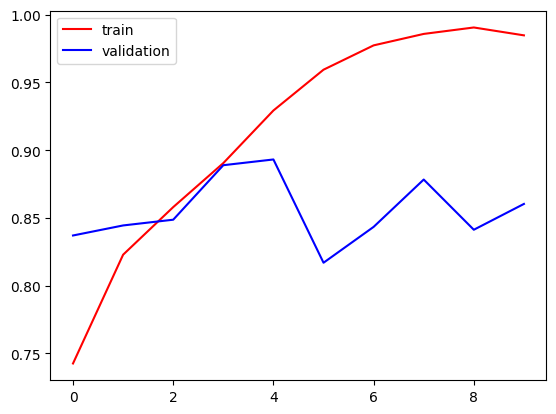

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

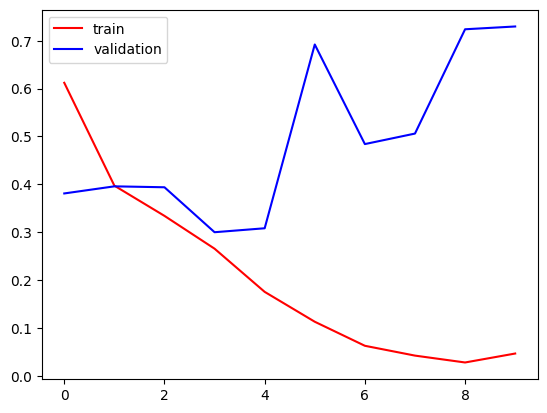

In [ ]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 1184 images belonging to 2 classes.


In [ ]:
#predict the test data
predictions = model.predict(test_data)


37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 209ms/step


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Assuming you have ground truth labels (true_labels) and predicted labels (predictions)
true_labels = test_data.classes
predicted_labels = (predictions > 0.5).astype(int)  # Adjust the threshold as needed

# Calculate confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Print classification report
print("Classification Report:")
print(classification_report(true_labels, predicted_labels))

Confusion Matrix:
[[545  95]
 [ 58 486]]
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.85      0.88       640
           1       0.84      0.89      0.86       544

    accuracy                           0.87      1184
   macro avg       0.87      0.87      0.87      1184
weighted avg       0.87      0.87      0.87      1184



There is overfitting and hence applying Batchnormalisation and Dropout techniques to handle overfitting

In [ ]:
# create CNN model

model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))  # 32 filters
model.add(BatchNormalization())  # added to reduce overfitting
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())  # added to reduce overfitting
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())  # added to reduce overfitting
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu')) #feature reduction
model.add(Dropout(0.1))  # added to reduce overfitting
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.1))  # added to reduce overfitting
model.add(Dense(1,activation='sigmoid'))  #output layer

In [ ]:
from keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
history = model.fit(train_data, epochs=10, validation_data=validation_data)

Epoch 1/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 30s 248ms/step - accuracy: 0.9337 - loss: 0.1795 - val_accuracy: 0.8656 - val_loss: 0.3414
Epoch 2/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 28s 233ms/step - accuracy: 0.9490 - loss: 0.1405 - val_accuracy: 0.8868 - val_loss: 0.2730
Epoch 3/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 27s 227ms/step - accuracy: 0.9625 - loss: 0.1042 - val_accuracy: 0.8857 - val_loss: 0.3461
Epoch 4/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 29s 242ms/step - accuracy: 0.9757 - loss: 0.0683 - val_accuracy: 0.8910 - val_loss: 0.3699
Epoch 5/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 32s 271ms/step - accuracy: 0.9776 - loss: 0.0667 - val_accuracy: 0.8910 - val_loss: 0.4101
Epoch 6/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 28s 234ms/step - accuracy: 0.9733 - loss: 0.0712 - val_accuracy: 0.9259 - val_loss: 0.2028
Epoch 7/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 27s 228ms/step - accuracy: 0.9776 - loss: 0.0633 - val_accuracy: 0.9069 - val_loss: 0.2964
Epoch 8/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 28s 231ms/step - accuracy: 0.9844 - loss: 0

In [ ]:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          test_datagen = ImageDataGenerator(rescale=1./255)
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 1184 images belonging to 2 classes.


In [ ]:
predictions = model.predict(test_data)

37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 211ms/step


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Assuming you have ground truth labels (true_labels) and predicted labels (predictions)
true_labels = test_data.classes
predicted_labels = (predictions > 0.5).astype(int)  # Adjust the threshold as needed

# Calculate confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Print classification report
print("Classification Report after applying techniques to handle overfitting:")
print(classification_report(true_labels, predicted_labels))

Confusion Matrix:
[[567  73]
 [ 38 506]]
Classification Report after applying techniques to handle overfitting:
              precision    recall  f1-score   support

           0       0.94      0.89      0.91       640
           1       0.87      0.93      0.90       544

    accuracy                           0.91      1184
   macro avg       0.91      0.91      0.91      1184
weighted avg       0.91      0.91      0.91      1184



Using Pre-trained model (Transfer learning) - Resnet50  -- 50 Convolutional layers + fully connected layer





In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
resnet_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

resnet_train_data = resnet_datagen.flow_from_directory(
    train_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary',
    subset='training'
)


resnet_validation_data = resnet_datagen.flow_from_directory(
    train_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)


resnet_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

resnet_test_data = resnet_test_datagen.flow_from_directory(
    test_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)
resnet_model = Sequential()    #ResNet50 is a pre-trained model
pretrained_model = tf.keras.applications.ResNet50(include_top = False, #because i have my own image of a diff dimension
                                                input_shape = (256,256,3),
                                                pooling = 'max', classes = 2,
                                                weights = 'imagenet')
for layer in pretrained_model.layers:
    layer.trainable = False  #all layers in the Resnet50 is not trainable; keep those weights; I am going to add my own i/p and other layers

resnet_model.add(pretrained_model)
resnet_model.add(Flatten())
resnet_model.add(Dense(512, activation = 'relu'))
resnet_model.add(Dense(1, activation = 'sigmoid'))

Found 3788 images belonging to 2 classes.
Found 945 images belonging to 2 classes.
Found 1184 images belonging to 2 classes.


In [ ]:
from keras.optimizers import Adam
resnet_model.compile(optimizer=Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
history = resnet_model.fit(train_data, epochs=10, validation_data=validation_data)

Epoch 1/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 51s 335ms/step - accuracy: 0.6917 - loss: 1.1054 - val_accuracy: 0.8392 - val_loss: 0.3858
Epoch 2/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 29s 245ms/step - accuracy: 0.7841 - loss: 0.4647 - val_accuracy: 0.8180 - val_loss: 0.4021
Epoch 3/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 29s 241ms/step - accuracy: 0.7476 - loss: 0.5775 - val_accuracy: 0.7323 - val_loss: 0.5489
Epoch 4/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 29s 242ms/step - accuracy: 0.8089 - loss: 0.4116 - val_accuracy: 0.8476 - val_loss: 0.3433
Epoch 5/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 33s 280ms/step - accuracy: 0.7951 - loss: 0.4644 - val_accuracy: 0.8466 - val_loss: 0.3460
Epoch 6/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 30s 248ms/step - accuracy: 0.8435 - loss: 0.3702 - val_accuracy: 0.8508 - val_loss: 0.3543
Epoch 7/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 30s 248ms/step - accuracy: 0.8398 - loss: 0.3764 - val_accuracy: 0.8328 - val_loss: 0.3701
Epoch 8/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 29s 245ms/step - accuracy: 0.8464 - loss: 0

In [ ]:
predictions = resnet_model.predict(test_data)

37/37 ━━━━━━━━━━━━━━━━━━━━ 12s 230ms/step


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Assuming you have ground truth labels (true_labels) and predicted labels (predictions)
true_labels = test_data.classes
predicted_labels = (predictions > 0.5).astype(int)  # Adjust the threshold as needed

# Calculate confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Print classification report
print("Classification Report after applying techniques to handle overfitting:")
print(classification_report(true_labels, predicted_labels))

Confusion Matrix:
[[478 162]
 [ 50 494]]
Classification Report after applying techniques to handle overfitting:
              precision    recall  f1-score   support

           0       0.91      0.75      0.82       640
           1       0.75      0.91      0.82       544

    accuracy                           0.82      1184
   macro avg       0.83      0.83      0.82      1184
weighted avg       0.84      0.82      0.82      1184

